In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
from scipy.stats import skew

In [8]:
df = pd.read_csv(r'C:\Users\dhruv\Downloads\synthetic_vehicle_dataset.csv')
df.head()

,Material_ID,Billing_Date,Billing_Quantity,Customer_ID
0,i560,05-12-2024,93.838382,1s210
1,e264,04-03-2026,8.403030,1s455
2,f848,13-07-2024,92.946352,1s340
3,e705,23-02-2026,76.370885,1s118
4,d944,09-01-2026,5.323565,1s401


In [9]:
print(df.shape)

(1000000, 4)


In [10]:
print(df.dtypes)

Material_ID          object
Billing_Date         object
Billing_Quantity    float64
Customer_ID          object
dtype: object


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Material_ID       1000000 non-null  object 
 1   Billing_Date      1000000 non-null  object 
 2   Billing_Quantity  1000000 non-null  float64
 3   Customer_ID       1000000 non-null  object 
dtypes: float64(1), object(3)
memory usage: 30.5+ MB
None


In [12]:
df['Billing_Date'] = pd.to_datetime(df['Billing_Date'], dayfirst=True)
df['Billing_Quantity'] = df['Billing_Quantity'].astype(float)
df['Material_ID'] = df['Material_ID'].astype(str)
df['Customer_ID'] = df['Customer_ID'].astype(str)

In [13]:
df['Billing_Quantity'] = df['Billing_Quantity'].round(0).astype(int)

In [15]:
print(df['Billing_Quantity'].dtype)   
df.head()

int32


,Material_ID,Billing_Date,Billing_Quantity,Customer_ID
0,i560,2024-12-05,94,1s210
1,e264,2026-03-04,8,1s455
2,f848,2024-07-13,93,1s340
3,e705,2026-02-23,76,1s118
4,d944,2026-01-09,5,1s401


In [16]:
print(df.isnull().sum())
print(df.isnull().mean() * 100)  

Material_ID         0
Billing_Date        0
Billing_Quantity    0
Customer_ID         0
dtype: int64
Material_ID         0.0
Billing_Date        0.0
Billing_Quantity    0.0
Customer_ID         0.0
dtype: float64


In [19]:
print("Number of Duplicate:" ,df.duplicated().sum())
print("Duplicate in subset:",df.duplicated(subset=['Material_ID', 'Billing_Date', 'Customer_ID']).sum())

Number of Duplicate: 0
Duplicate in subset: 136


count    1000000.000000
mean          49.976602
std           28.723621
min          -11.000000
25%           25.000000
50%           50.000000
75%           75.000000
max          111.000000
Name: Billing_Quantity, dtype: float64


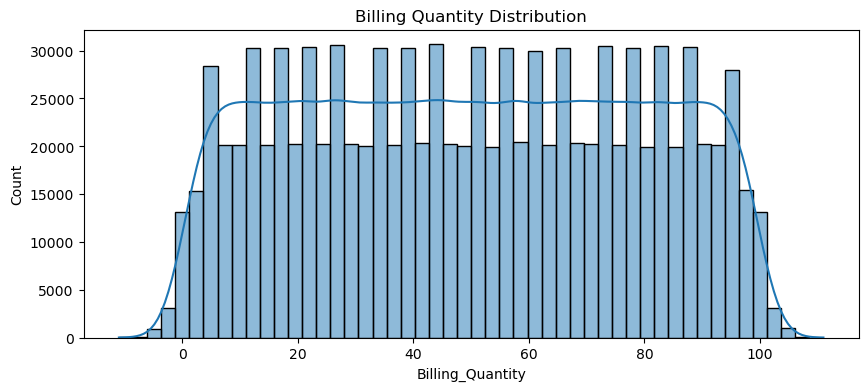

In [23]:
# Univariate Analysis: Billing_Quantity
print(df['Billing_Quantity'].describe())

# Distribution with histogram
plt.figure(figsize=(10,4))
sns.histplot(df['Billing_Quantity'], bins=50, kde=True)
plt.title('Billing Quantity Distribution')
plt.show()

In [24]:
#Outliers Detection 
Q1 = df['Billing_Quantity'].quantile(0.25)
Q3 = df['Billing_Quantity'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Billing_Quantity'] < Q1 - 1.5*IQR) | (df['Billing_Quantity'] > Q3 + 1.5*IQR)]
print(f"Outlier count: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Outlier count: 0 (0.00%)


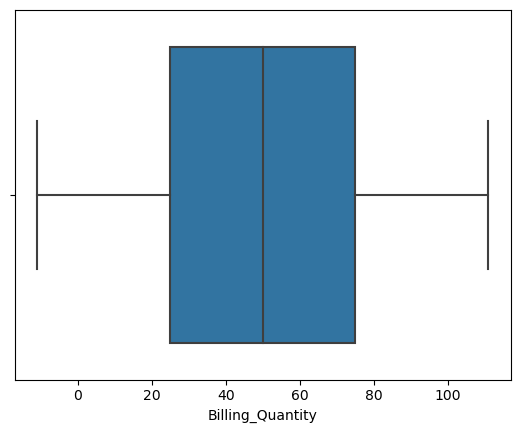

In [22]:
# Box plot for outliers
sns.boxplot(x=df['Billing_Quantity'])
plt.show()

Unique Materials: 10000
Unique Customers: 500
Top Materials by Freq:


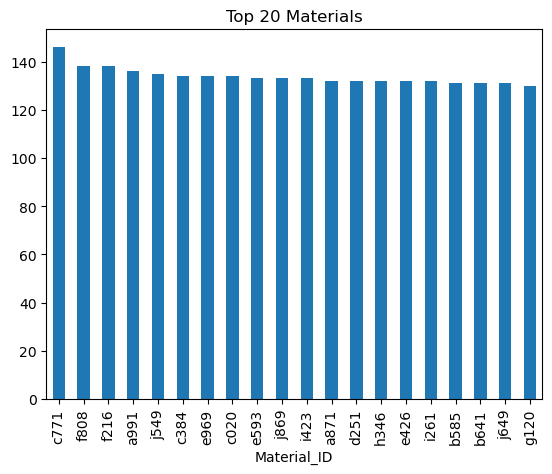

In [31]:
#Univariate Analysis: Categorical Columns(Material)
print(f"Unique Materials: {df['Material_ID'].nunique()}")
print(f"Unique Customers: {df['Customer_ID'].nunique()}")

print(f"Top Materials by Freq:")
df['Material_ID'].value_counts().head(20).plot(kind='bar', title='Top 20 Materials')
plt.show()

Top Customers by Freq:


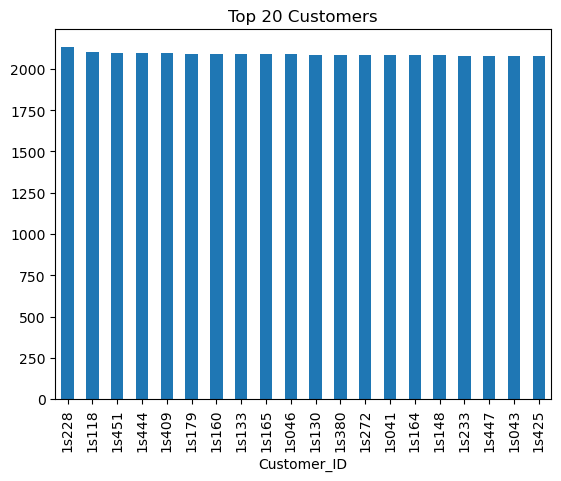

In [32]:
#Univariate Analysis: Categorical Columns(Customers)
print(f"Top Customers by Freq:")
df['Customer_ID'].value_counts().head(20).plot(kind='bar', title='Top 20 Customers')
plt.show()

Date range: 2024-04-01 00:00:00 to 2026-03-31 00:00:00
Monthly billing volume


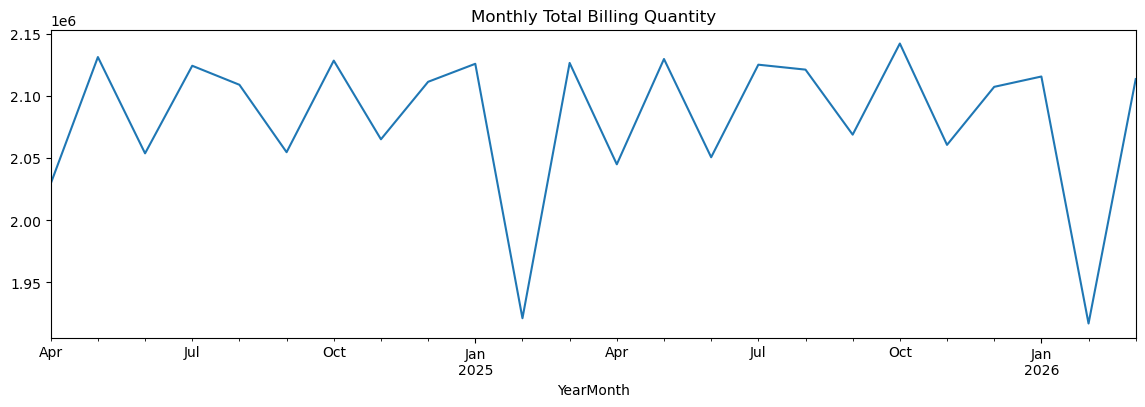

In [36]:
#Time Analysis (Billing_Date)
print(f"Date range: {df['Billing_Date'].min()} to {df['Billing_Date'].max()}")

print(f"Monthly billing volume")
df['YearMonth'] = df['Billing_Date'].dt.to_period('M')
monthly = df.groupby('YearMonth')['Billing_Quantity'].sum()
monthly.plot(kind='line', figsize=(14,4), title='Monthly Total Billing Quantity')
plt.show()


Day of week pattern


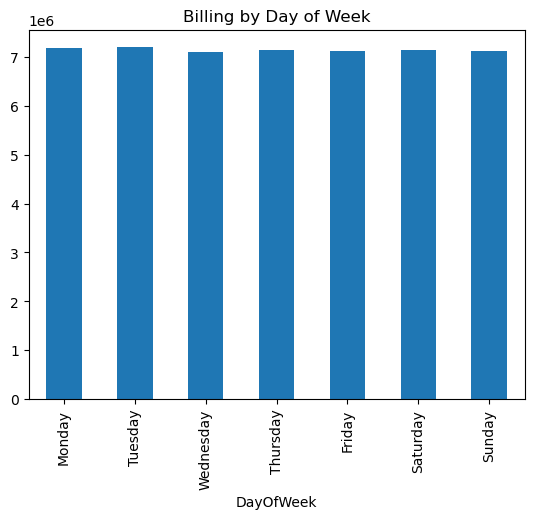

In [35]:
#Time Series (Billing_Date)
print(f"Day of week pattern")
df['DayOfWeek'] = df['Billing_Date'].dt.day_name()
df.groupby('DayOfWeek')['Billing_Quantity'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar', title='Billing by Day of Week')
plt.show()

       total_quantity  order_count  avg_quantity  unique_materials
count      500.000000    500.00000    500.000000        500.000000
mean     99953.204000   2000.00000     49.976460       1812.182000
std       2557.665845     44.20507      0.630271         37.317262
min      93174.000000   1873.00000     47.932601       1712.000000
25%      98066.500000   1971.00000     49.565341       1786.000000
50%      99818.000000   2001.00000     49.973311       1814.000000
75%     101880.000000   2032.00000     50.401394       1839.000000
max     107653.000000   2132.00000     52.045386       1915.000000
Top 10 Customer by Quantity


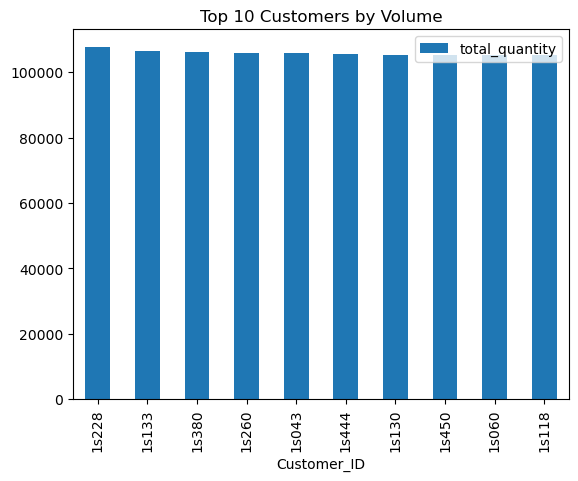

In [38]:
#Customer Behavior Analysis
#Customer Statics (mean,sd,min)
customer_stats = df.groupby('Customer_ID').agg(
    total_quantity=('Billing_Quantity', 'sum'),
    order_count=('Billing_Quantity', 'count'),
    avg_quantity=('Billing_Quantity', 'mean'),
    unique_materials=('Material_ID', 'nunique')
).reset_index()

print(customer_stats.describe())

print(f"Top 10 Customer by Quantity")
customer_stats.nlargest(10, 'total_quantity').plot(
    x='Customer_ID', y='total_quantity', kind='bar', title='Top 10 Customers by Volume'
)
plt.show()

In [41]:
#Material Performance Analysis
material_stats = df.groupby('Material_ID').agg(
    total_quantity=('Billing_Quantity', 'sum'),
    order_count=('Billing_Quantity', 'count'),
    unique_customers=('Customer_ID', 'nunique')
).reset_index()

material_stats_sorted = material_stats.sort_values('total_quantity', ascending=False)
material_stats_sorted['cumulative_pct'] = material_stats_sorted['total_quantity'].cumsum() / material_stats_sorted['total_quantity'].sum() * 100
print(material_stats_sorted.head(20))

     Material_ID  total_quantity  order_count  unique_customers  \
8584        i593            7310          125               106   
9539        j549            7220          135               119   
4512        e517            7133          127               116   
7974        h982            7079          128               109   
4464        e469            7056          126               112   
2973        c976            7025          119               103   
888         a889            6987          130               110   
2125        c128            6985          125               111   
2768        c771            6972          146               130   
8085        i094            6966          127               112   
4964        e969            6906          134               122   
5802        f808            6863          138               124   
4706        e711            6835          122               110   
4588        e593            6827          133               12

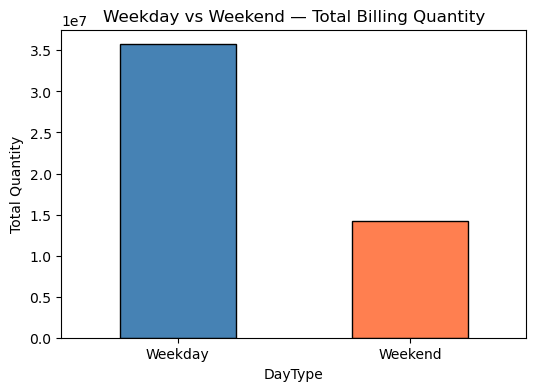

In [57]:
#Quantity Sold on WeekDay vs WeekEnd 
#Operational patterns 
df['DayType'] = df['Billing_Date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

df.groupby('DayType')['Billing_Quantity'].sum().plot(
    kind='bar', color=['steelblue', 'coral'], edgecolor='black', figsize=(6,4)
)
plt.title('Weekday vs Weekend — Total Billing Quantity')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)
plt.show()

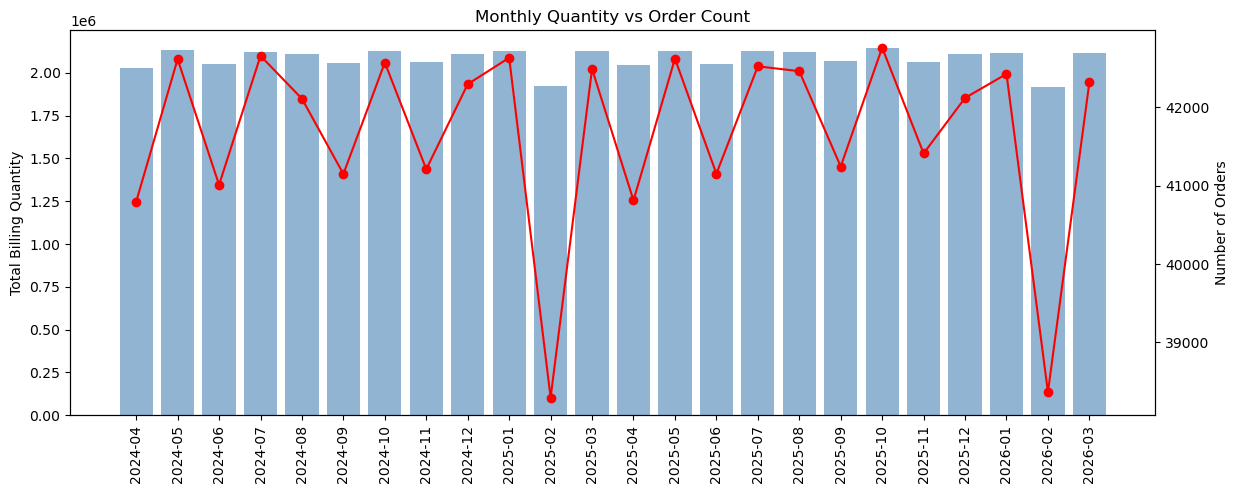

In [58]:
#Monthly Order Count (Volume,Frequency)
fig, ax1 = plt.subplots(figsize=(14,5))

monthly_qty = df.groupby(df['Billing_Date'].dt.to_period('M'))['Billing_Quantity'].sum()
monthly_cnt = df.groupby(df['Billing_Date'].dt.to_period('M'))['Billing_Quantity'].count()

ax1.bar(monthly_qty.index.astype(str), monthly_qty, color='steelblue', alpha=0.6, label='Total Quantity')
ax2 = ax1.twinx()
ax2.plot(monthly_cnt.index.astype(str), monthly_cnt, color='red', marker='o', label='Order Count')

ax1.set_title('Monthly Quantity vs Order Count')
ax1.set_ylabel('Total Billing Quantity')
ax2.set_ylabel('Number of Orders')
ax1.tick_params(axis='x', rotation=90)
plt.show()

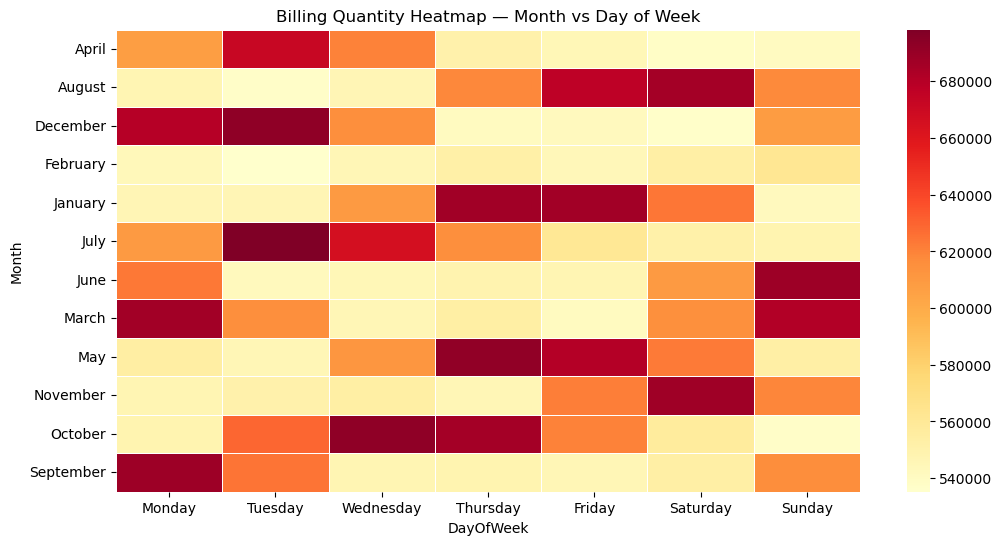

In [59]:
#Which day of which month is busiest
df['DayOfWeek'] = df['Billing_Date'].dt.day_name()
df['Month'] = df['Billing_Date'].dt.month_name()

pivot = df.groupby(['Month', 'DayOfWeek'])['Billing_Quantity'].sum().unstack()
pivot = pivot[['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']]

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, linewidths=0.5)
plt.title('Billing Quantity Heatmap — Month vs Day of Week')
plt.show()

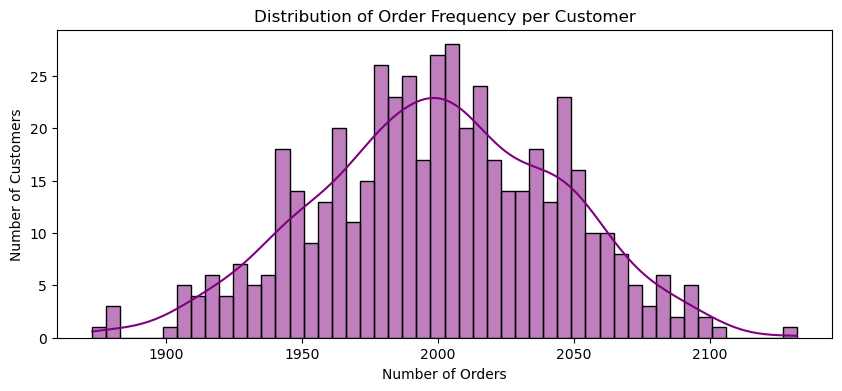

In [63]:
order_counts = df.groupby('Customer_ID')['Billing_Quantity'].count()

plt.figure(figsize=(10,4))
sns.histplot(order_counts, bins=50, kde=True, color='purple')
plt.title('Distribution of Order Frequency per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()

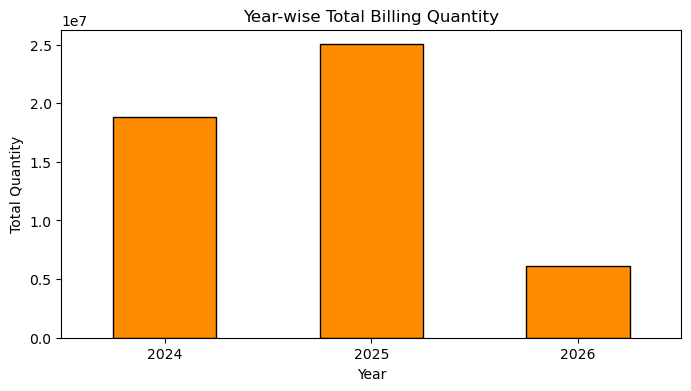

In [64]:
df['Year'] = df['Billing_Date'].dt.year

df.groupby('Year')['Billing_Quantity'].sum().plot(
    kind='bar', color='darkorange', edgecolor='black', figsize=(8,4)
)
plt.title('Year-wise Total Billing Quantity')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)
plt.show()

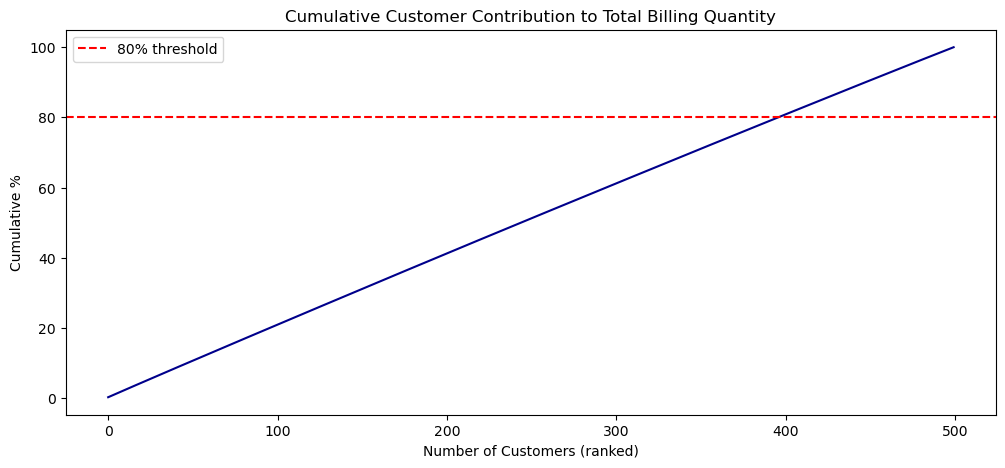

Top 396 customers contribute 80% of total billing quantity


In [67]:
#How many customer you cant afford to lose (80% - 400 customer)
cust_sorted = df.groupby('Customer_ID')['Billing_Quantity'].sum().sort_values(ascending=False)
cust_cumulative = (cust_sorted.cumsum() / cust_sorted.sum() * 100)

plt.figure(figsize=(12,5))
plt.plot(range(len(cust_cumulative)), cust_cumulative.values, color='darkblue')
plt.axhline(80, color='red', linestyle='--', label='80% threshold')
plt.title('Cumulative Customer Contribution to Total Billing Quantity')
plt.xlabel('Number of Customers (ranked)')
plt.ylabel('Cumulative %')
plt.legend()
plt.show()

# Find exact number of customers for 80%
cutoff = (cust_cumulative <= 80).sum()
print(f"Top {cutoff} customers contribute 80% of total billing quantity")

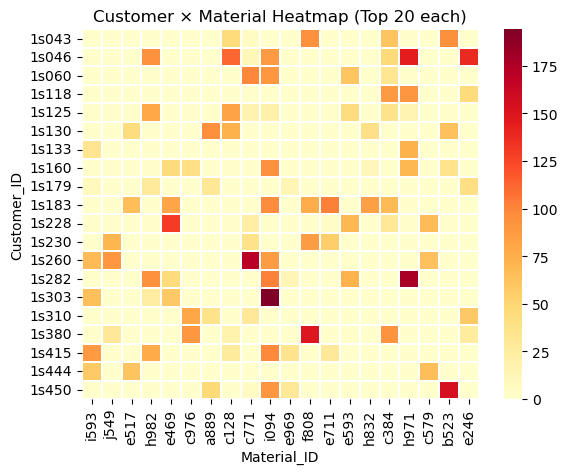

In [46]:
# Bivariate Analysis (Customer , Material)
cross = df.groupby(['Customer_ID', 'Material_ID'])['Billing_Quantity'].sum().reset_index()
pivot = cross.pivot_table(index='Customer_ID', columns='Material_ID', values='Billing_Quantity', fill_value=0)

top_custs = customer_stats.nlargest(20, 'total_quantity')['Customer_ID']
top_mats = material_stats.nlargest(20, 'total_quantity')['Material_ID']
sub_pivot = pivot.loc[pivot.index.isin(top_custs), top_mats]
sns.heatmap(sub_pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('Customer × Material Heatmap (Top 20 each)')
plt.show()

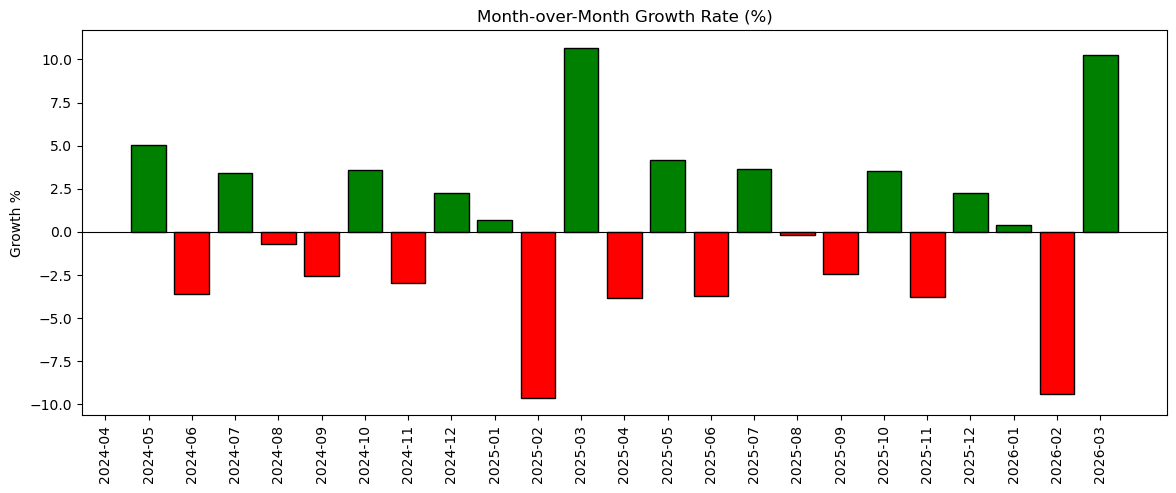

In [74]:
monthly_qty = df.groupby(df['Billing_Date'].dt.to_period('M'))['Billing_Quantity'].sum()
mom_growth = monthly_qty.pct_change() * 100  # % change vs previous month

plt.figure(figsize=(14,5))
colors = ['green' if x >= 0 else 'red' for x in mom_growth.values]
plt.bar(mom_growth.index.astype(str), mom_growth.values, color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Month-over-Month Growth Rate (%)')
plt.ylabel('Growth %')
plt.xticks(rotation=90)
plt.show()

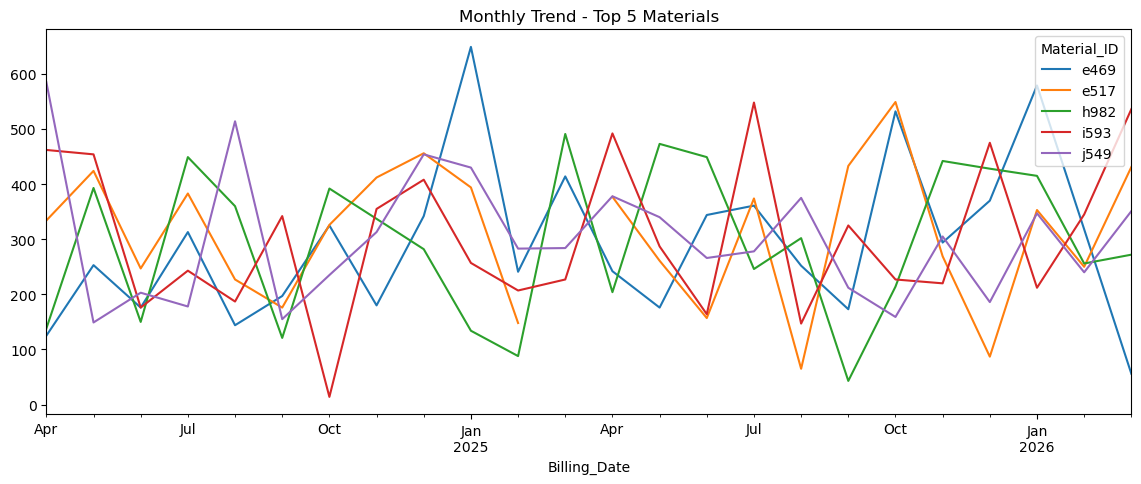

In [47]:
#Trend per Top 5 Materials Over Period of Time
top5_materials = material_stats.nlargest(5, 'total_quantity')['Material_ID'].tolist()
df_top = df[df['Material_ID'].isin(top5_materials)]
monthly_mat = df_top.groupby([df_top['Billing_Date'].dt.to_period('M'), 'Material_ID'])['Billing_Quantity'].sum().unstack()
monthly_mat.plot(figsize=(14,5), title='Monthly Trend - Top 5 Materials')
plt.show()

In [49]:
#Statistical Summary
print(f"Quantity vs order frequency per customer")
print(customer_stats[['total_quantity','order_count','avg_quantity']].corr())

print(f"Skewness: {df['Billing_Quantity'].skew():.4f}")
print(f"Kurtosis: {df['Billing_Quantity'].kurt():.4f}")

Quantity vs order frequency per customer
                total_quantity  order_count  avg_quantity
total_quantity        1.000000     0.870201      0.501440
order_count           0.870201     1.000000      0.010193
avg_quantity          0.501440     0.010193      1.000000
Skewness: 0.0011
Kurtosis: -1.1757


In [56]:
#Final Summary 
summary = {
    "Total Records": len(df),
    "Date Range": f"{df['Billing_Date'].min().date()} to {df['Billing_Date'].max().date()}",
    "Unique Materials": df['Material_ID'].nunique(),
    "Unique Customers": df['Customer_ID'].nunique(),
    "Total Billing Quantity": df['Billing_Quantity'].sum(),
    "Avg Billing Quantity": df['Billing_Quantity'].mean(),
    "Null Values": df.isnull().sum().to_dict(),
    "Duplicates": df.duplicated().sum()
}
for k, v in summary.items():
    print(f"{k}: {v}")

Total Records: 1000000
Date Range: 2024-04-01 to 2026-03-31
Unique Materials: 10000
Unique Customers: 500
Total Billing Quantity: 49976602
Avg Billing Quantity: 49.976602
Null Values: {'Material_ID': 0, 'Billing_Date': 0, 'Billing_Quantity': 0, 'Customer_ID': 0, 'YearMonth': 0, 'DayOfWeek': 0}
Duplicates: 0
